In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chargement du panel
df = pd.read_csv('panel.csv')



In [2]:
# 2. Stats descriptives complètes (Moyenne, Médiane, Écart-type, etc.)
# .T permet de mettre les variables en lignes pour mieux lire
print("Statistiques descriptives du panel :")
display(df.describe().T)

Statistiques descriptives du panel :


,count,mean,std,min,25%,50%,75%,max
Depenses de sante en % du PIB,380.0,8.445984,1.816107,4.973000,6.851500,8.522500,9.861250,12.724000
PIB par habitant,380.0,104.756316,69.673194,26.700000,53.975000,82.000000,136.400000,345.500000
Part des +65 ans,380.0,0.179241,0.027780,0.107764,0.163545,0.181647,0.199363,0.240372
Practiciens pour 1000 habitants,359.0,3.680641,0.859573,2.140000,3.145000,3.480000,4.040000,6.610000
Lits d hôpitaux pour 1000 habitants,365.0,5.175397,1.456483,2.510000,3.980000,5.520000,6.170000,7.930000
Taux deces 2 ans,363.0,2.088920,0.412846,1.240000,1.878500,1.994000,2.326000,3.451000
Depenses t-1,380.0,8.399008,1.806148,4.973000,6.745500,8.461000,9.819000,12.724000


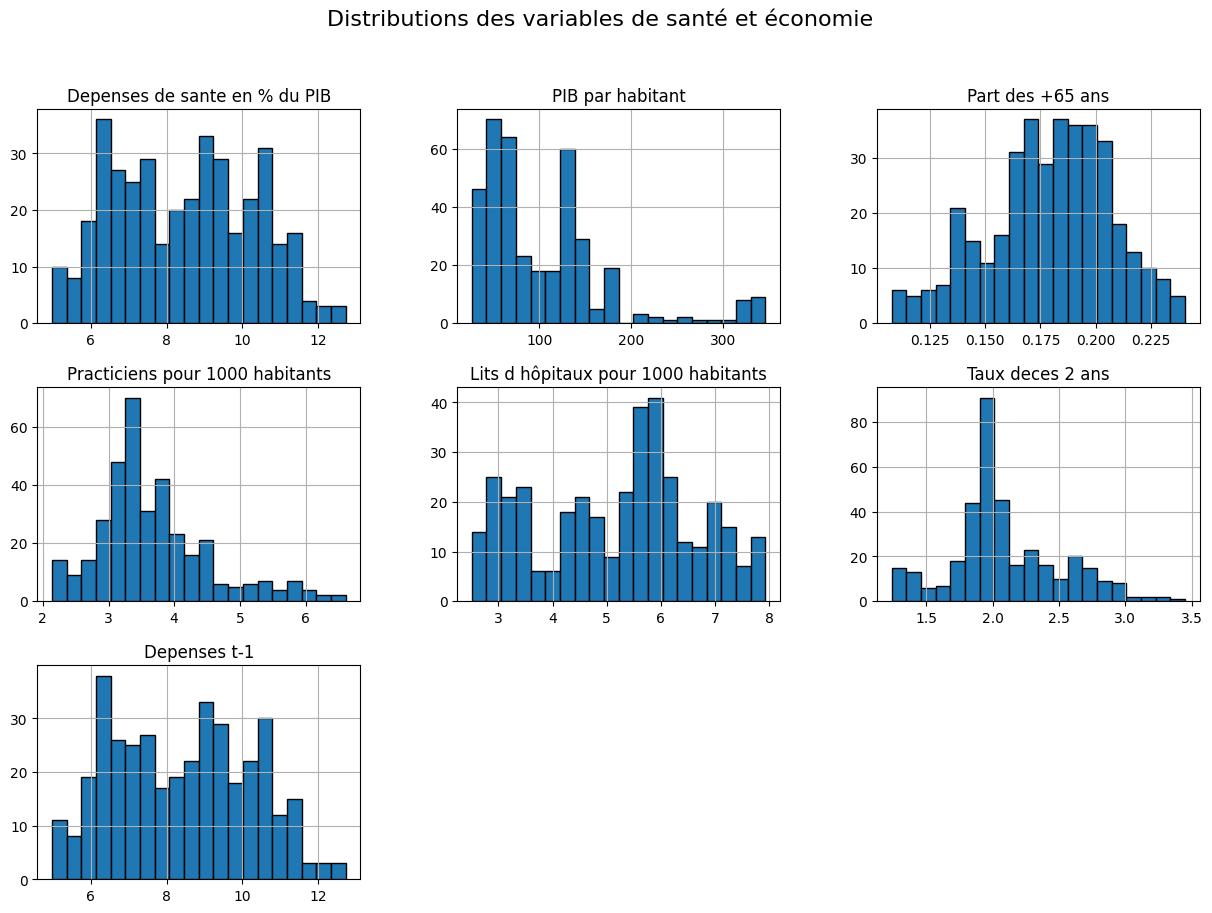

In [3]:
# 3. Visualisation : Histogrammes pour voir la distribution de chaque variable
df.hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.suptitle("Distributions des variables de santé et économie", fontsize=16)
plt.show()



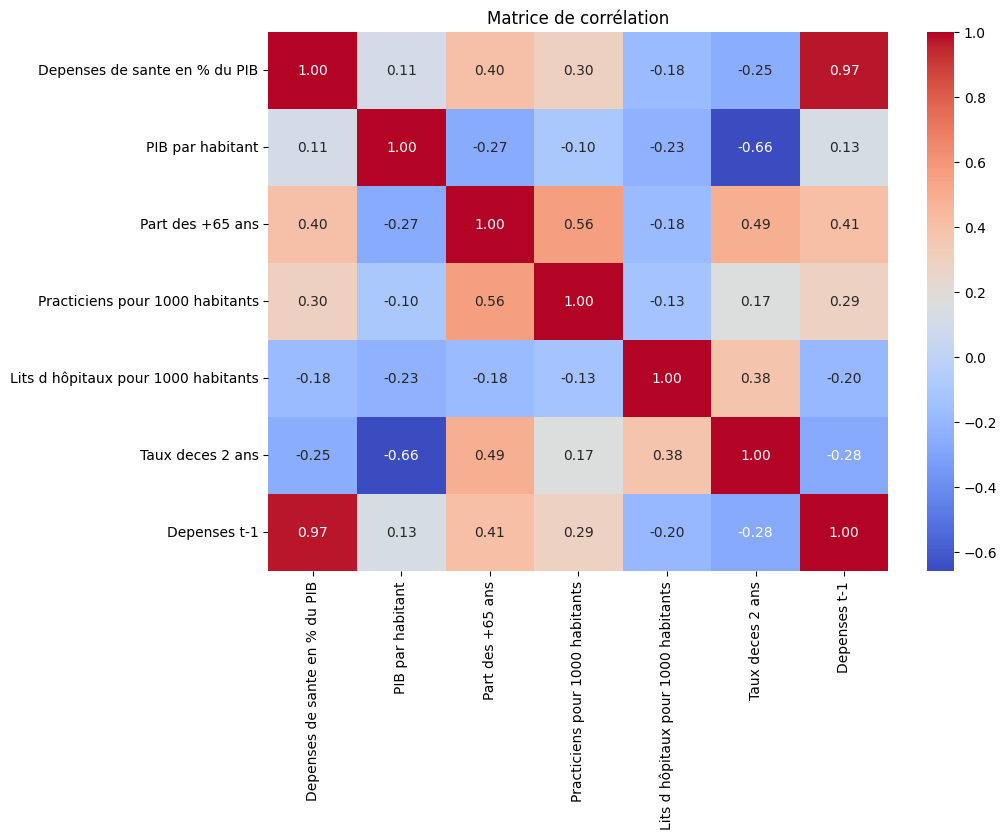

In [ ]:
# 4. Matrice de corrélation
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

Analyse de la forme des distributions :


,Moyenne,Médiane,Écart-type,Skewness,Kurtosis,Manquants
Depenses de sante en % du PIB,8.445984,8.522500,1.816107,0.083173,-1.039906,0
PIB par habitant,104.756316,82.000000,69.673194,1.702137,3.061583,0
Part des +65 ans,0.179241,0.181647,0.027780,-0.326419,-0.261385,0
Practiciens pour 1000 habitants,3.680641,3.480000,0.859573,1.024692,1.157528,21
Lits d hôpitaux pour 1000 habitants,5.175397,5.520000,1.456483,-0.152655,-1.010191,15
Taux deces 2 ans,2.088920,1.994000,0.412846,0.482083,0.302631,17
Depenses t-1,8.399008,8.461000,1.806148,0.092632,-1.021171,0


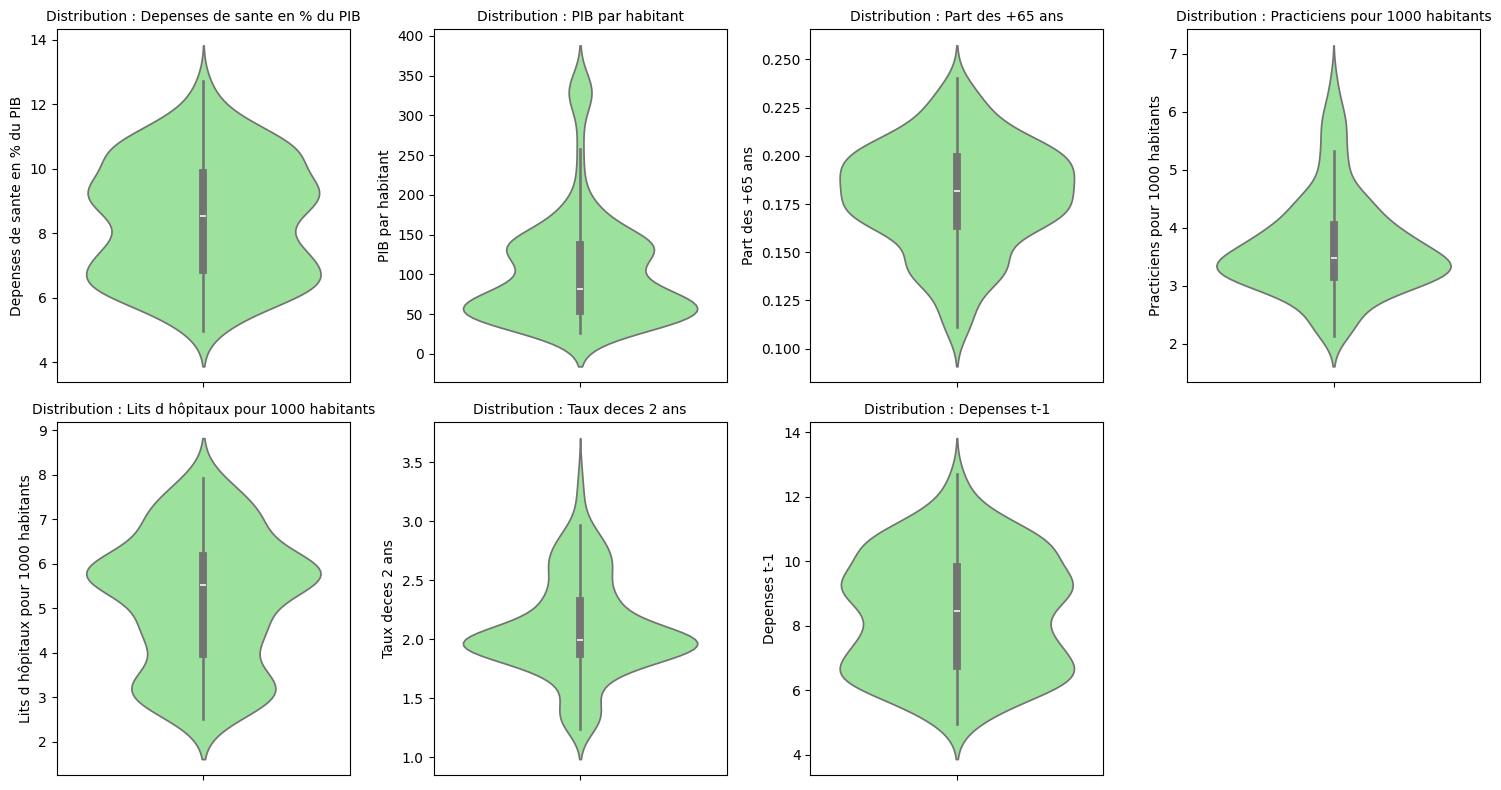

In [5]:
# --- Statistiques univariées avancées ---
# Skewness (asymétrie) : >0 (queue à droite), <0 (queue à gauche)
# Kurtosis (aplatissement) : >3 (pointu), <3 (aplati)
univ_stats = pd.DataFrame({
    'Moyenne': df.mean(),
    'Médiane': df.median(),
    'Écart-type': df.std(),
    'Skewness': df.skew(),
    'Kurtosis': df.kurt(),
    'Manquants': df.isnull().sum()
})
print("Analyse de la forme des distributions :")
display(univ_stats)

# --- Graphique : Violin Plots ---
# Les Violin plots combinent une boîte à moustaches et une courbe de densité
plt.figure(figsize=(15, 8))
for i, col in enumerate(df.columns):
    plt.subplot(2, 4, i+1)
    sns.violinplot(y=df[col], color="lightgreen")
    plt.title(f"Distribution : {col}", fontsize=10)
plt.tight_layout()
plt.show()

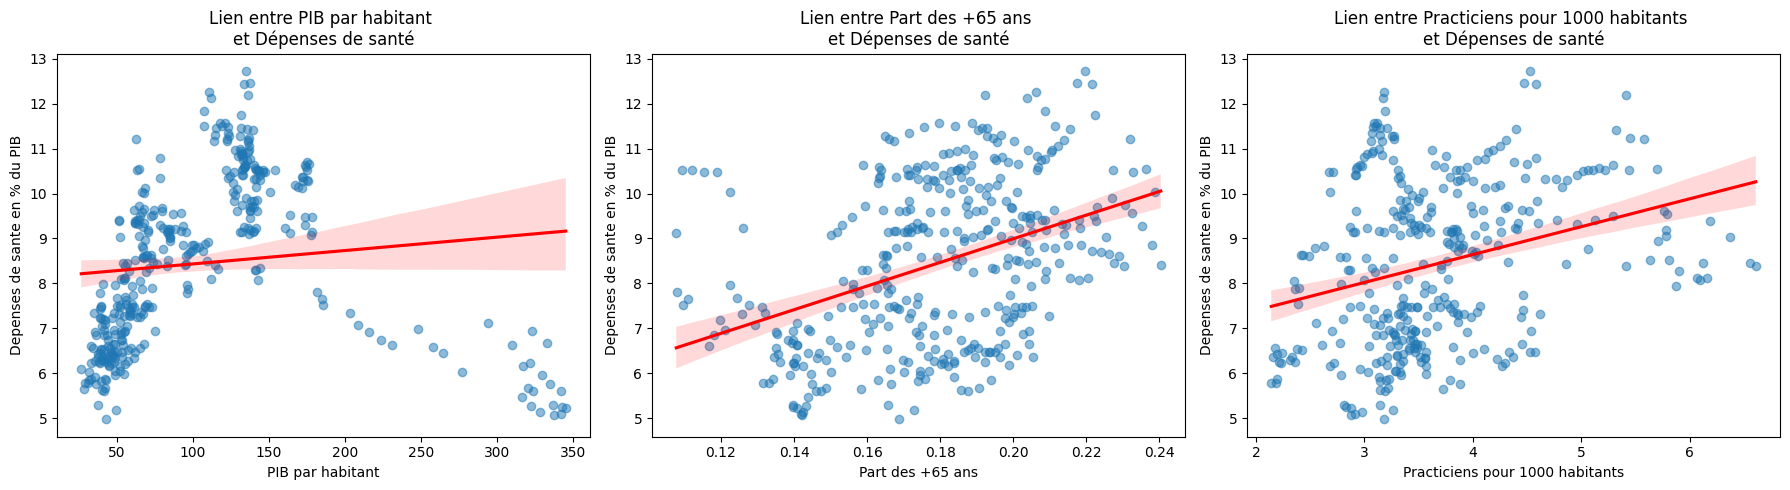

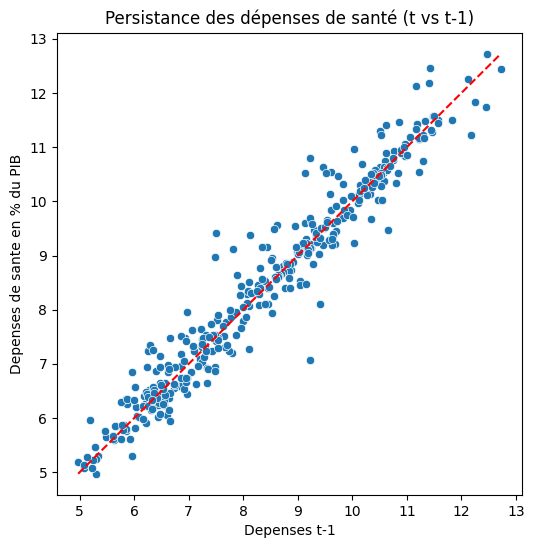

In [6]:
# 2. Stats bivariées
# --- Graphiques de dispersion avec droite de régression ---
# On compare la variable cible (Dépenses de santé) avec les autres
variables_a_tester = ['PIB par habitant', 'Part des +65 ans', 'Practiciens pour 1000 habitants']

plt.figure(figsize=(18, 5))
for i, var in enumerate(variables_a_tester):
    plt.subplot(1, 3, i+1)
    sns.regplot(data=df, x=var, y='Depenses de sante en % du PIB', 
                scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title(f"Lien entre {var} \net Dépenses de santé")

plt.tight_layout()
plt.show()

# --- Analyse de la persistance (Auto-corrélation) ---
# Lien entre les dépenses actuelles et les dépenses passées (Depenses t-1)
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df, x='Depenses t-1', y='Depenses de sante en % du PIB')
plt.title("Persistance des dépenses de santé (t vs t-1)")
plt.plot([df['Depenses t-1'].min(), df['Depenses t-1'].max()], 
         [df['Depenses t-1'].min(), df['Depenses t-1'].max()], 'r--') # Ligne à 45°
plt.show()

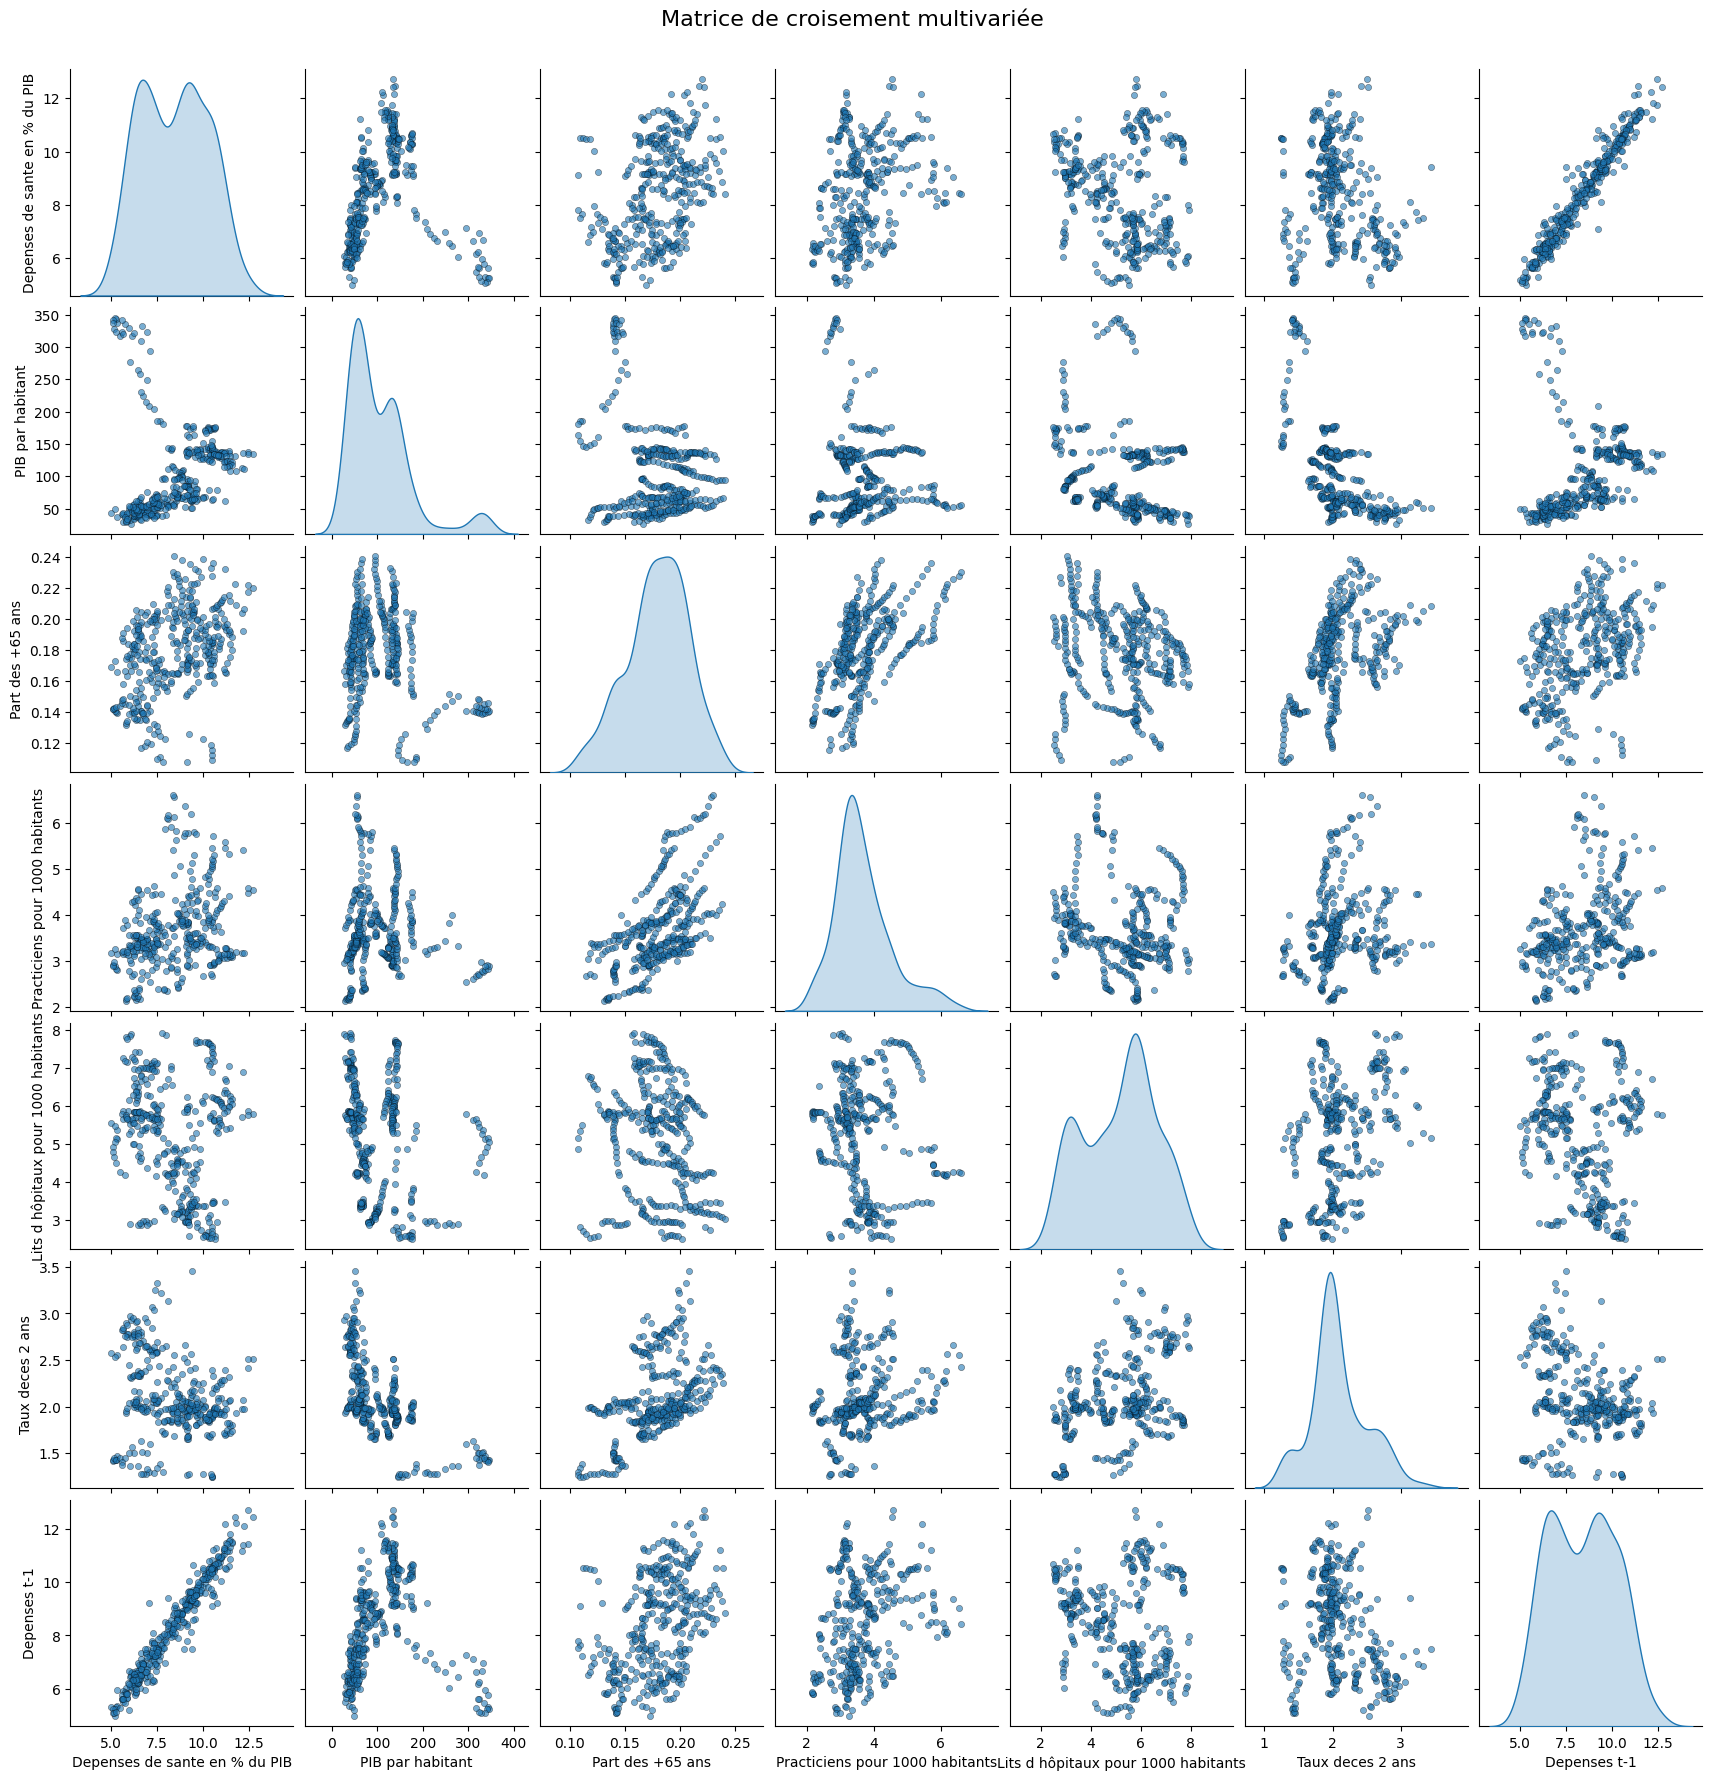

Nombre d'observations extrêmes (outliers) détectées : 0


In [7]:
# 3. Stats multivariées

# --- Le Pair-Plot : La "vue d'ensemble" ---
# Crée une matrice de graphiques (croisement de chaque variable avec toutes les autres)
# Attention : peut être lent si vous avez des milliers de lignes
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha':0.6, 's':20, 'edgecolor':'k'})
plt.suptitle("Matrice de croisement multivariée", y=1.02, fontsize=16)
plt.show()

# --- Analyse des Outliers Multivariés (Z-Score) ---
# Identifier les observations qui s'éloignent de la norme sur plusieurs critères
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df.dropna()))
outliers = (z_scores > 3).all(axis=1)
print(f"Nombre d'observations extrêmes (outliers) détectées : {outliers.sum()}")